Descargando dataset...

=== DATASET ORIGINAL ===
Shape original: (541909, 8)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  

Columnas:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Coun

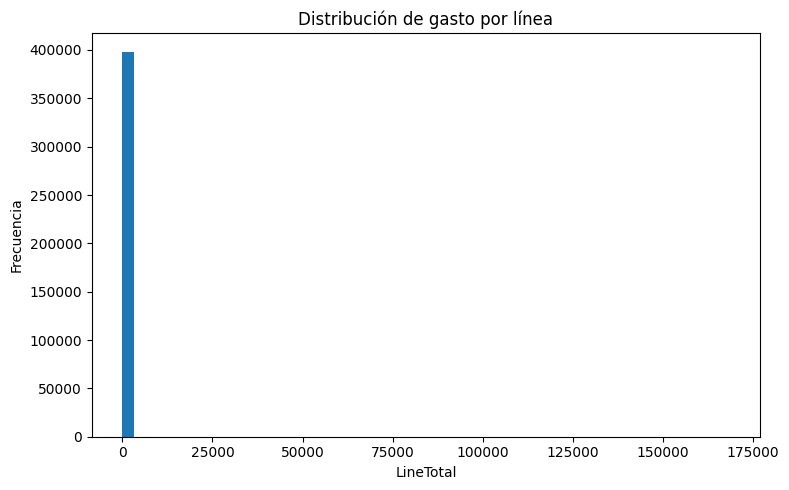


=== TABLA POR FACTURA ===
   CustomerID InvoiceNo         InvoiceDate         Country  invoice_total  \
0       12346    541431 2011-01-18 10:01:00  United Kingdom       77183.60   
1       12347    537626 2010-12-07 14:57:00         Iceland         711.79   
2       12347    542237 2011-01-26 14:30:00         Iceland         475.39   
3       12347    549222 2011-04-07 10:43:00         Iceland         636.25   
4       12347    556201 2011-06-09 13:01:00         Iceland         382.52   

   total_qty  n_lines  n_products  mean_unit_price  
0      74215        1           1         1.040000  
1        319       31          31         2.890000  
2        315       29          29         2.523103  
3        483       24          24         2.595417  
4        196       18          18         2.978889  
Shape invoice: (18562, 9)

=== TABLA FINAL POR CLIENTE ===
   CustomerID           AOV  n_invoices       avg_qty  avg_lines  \
0       12346  77183.600000           1  74215.000000      

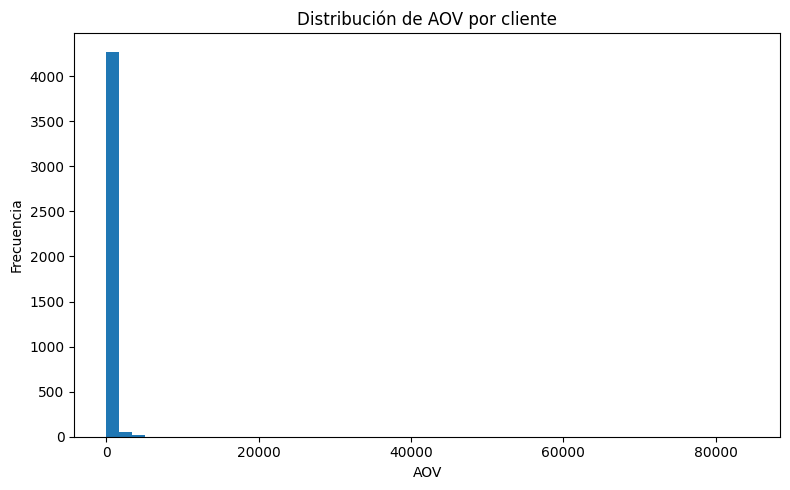


=== SPLIT ===
X_train: (3470, 9)
X_test : (868, 9)
y_train: (3470,)
y_test : (868,)

Variables numéricas: ['CustomerID', 'n_invoices', 'avg_qty', 'avg_lines', 'avg_products', 'avg_unit_price', 'recency_days', 'tenure_days']
Variables categóricas: ['country']

=== VALIDACIÓN CRUZADA ===
{'model': 'LinearRegression', 'MAE_cv': np.float64(158.50836343685987), 'RMSE_cv': np.float64(998.5706607214573), 'R2_cv': np.float64(0.5980398541047764)}
{'model': 'Ridge', 'MAE_cv': np.float64(157.15646792683165), 'RMSE_cv': np.float64(994.8714147738826), 'R2_cv': np.float64(0.6009476001850761)}
{'model': 'Lasso', 'MAE_cv': np.float64(155.5650967920266), 'RMSE_cv': np.float64(992.2847767873329), 'R2_cv': np.float64(0.6014759971294164)}
{'model': 'KNNRegressor', 'MAE_cv': np.float64(209.63506462090967), 'RMSE_cv': np.float64(1169.640849562111), 'R2_cv': np.float64(0.32315272557733155)}
{'model': 'GradientBoosting', 'MAE_cv': np.float64(118.73920450102999), 'RMSE_cv': np.float64(732.2668210913212), 'R2_

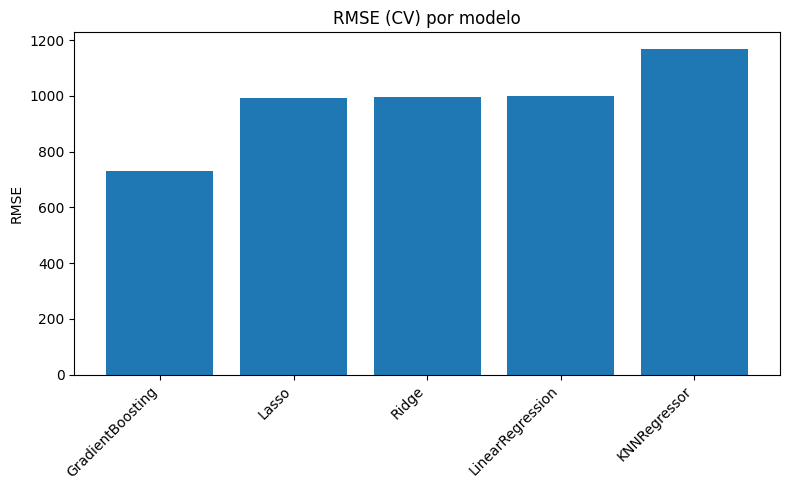


=== GRID SEARCH ===
Best Ridge: {'model__alpha': 100} RMSE CV: 964.0192758098774
Best Lasso: {'model__alpha': 1} RMSE CV: 992.2847767873329
Best KNN  : {'model__n_neighbors': 3} RMSE CV: 1021.5711580941246

=== EVALUACIÓN EN TEST ===
Evaluated BestRidge: MAE=116.19, RMSE=245.02, R2=0.64
Evaluated BestLasso: MAE=116.25, RMSE=246.08, R2=0.64
Evaluated BestKNN: MAE=184.06, RMSE=380.88, R2=0.13
Evaluated GradientBoosting: MAE=87.16, RMSE=203.87, R2=0.75

=== RESULTADOS TEST ===
              model    MAE_test   RMSE_test   R2_test
0  GradientBoosting   87.155653  203.869592  0.749663
1         BestRidge  116.185860  245.023448  0.638394
2         BestLasso  116.246711  246.075408  0.635282
3           BestKNN  184.055499  380.878866  0.126236

=== MEJOR MODELO FINAL: GradientBoosting ===
MAE : 87.15565258288392
RMSE: 203.8695915490006
R2  : 0.7496628798136182


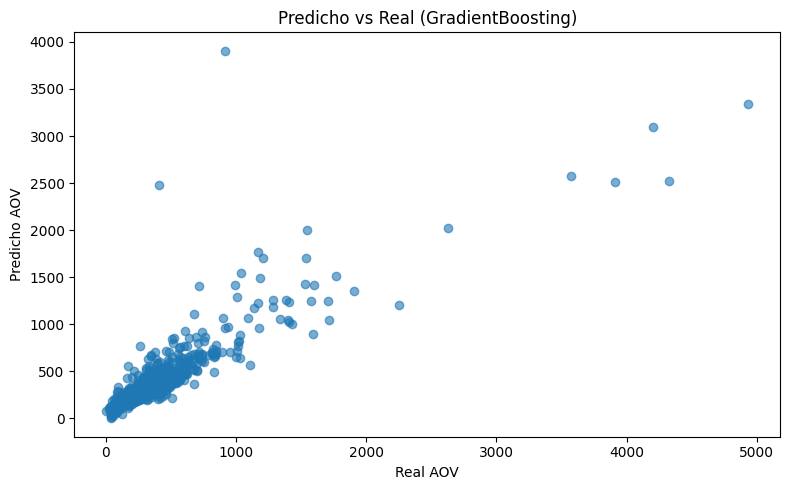

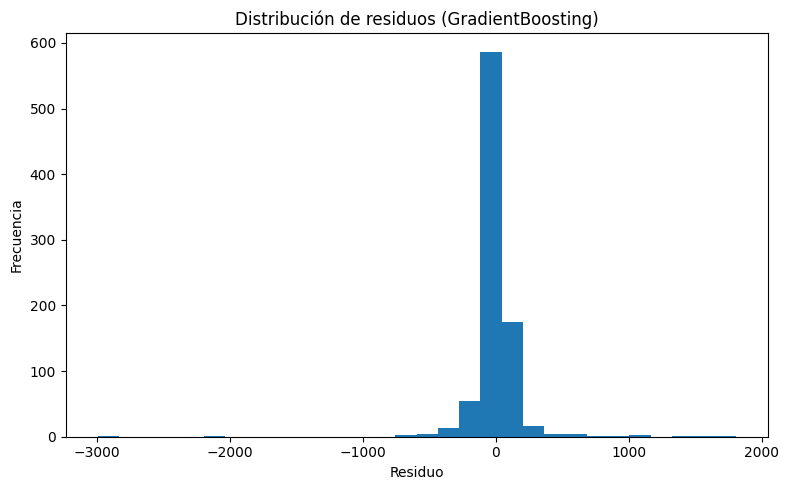


=== PARTE CONCEPTUAL DE CLASIFICACIÓN (KNN Classifier) ===
Accuracy: 0.6900921658986175
Matriz de confusión:
[[319 115]
 [154 280]]

Reporte:
              precision    recall  f1-score   support

           0       0.67      0.74      0.70       434
           1       0.71      0.65      0.68       434

    accuracy                           0.69       868
   macro avg       0.69      0.69      0.69       868
weighted avg       0.69      0.69      0.69       868


RESUMEN FINAL
1. Problema principal: REGRESIÓN
2. Target: AOV (Average Order Value) por cliente
3. Modelos evaluados: ['LinearRegression', 'Ridge', 'Lasso', 'KNNRegressor', 'GradientBoosting']
4. Mejor modelo en test: GradientBoosting
5. Archivos guardados:
   - results/cv_metrics.csv
   - results/test_metrics.csv
   - reports/figures/rmse_cv_por_modelo.png
   - reports/figures/predicho_vs_real_gb.png
   - reports/figures/residuos_gb.png


In [4]:
# =========================================================
# PROYECTO MÓDULO 6 - SCRIPT ÚNICO PARA COLAB
# Predicción del gasto promedio por cliente (AOV)
# =========================================================

# -------------------------
# 0) Librerías
# -------------------------
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

# -------------------------
# 1) Carpetas de salida
# -------------------------
os.makedirs("reports/figures", exist_ok=True)
os.makedirs("results", exist_ok=True)

# -------------------------
# 2) Descargar dataset
# -------------------------
print("Descargando dataset...")
!wget -q -O online_retail.xlsx "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"

# -------------------------
# 3) Cargar dataset
# -------------------------
df = pd.read_excel("online_retail.xlsx")
print("\n=== DATASET ORIGINAL ===")
print("Shape original:", df.shape)
print(df.head())

print("\nColumnas:")
print(df.columns.tolist())

print("\nNulos:")
print(df.isnull().sum())

# -------------------------
# 4) Limpieza básica
# -------------------------
df = df.copy()

# eliminar filas sin cliente
df = df.dropna(subset=["CustomerID"])

# tipado
df["CustomerID"] = df["CustomerID"].astype(int)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["InvoiceNo"] = df["InvoiceNo"].astype(str)

# eliminar cancelaciones
df = df[~df["InvoiceNo"].str.startswith("C")]

# eliminar precios o cantidades no positivos
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

# total por línea
df["LineTotal"] = df["Quantity"] * df["UnitPrice"]

print("\n=== DATASET LIMPIO ===")
print("Shape limpio:", df.shape)
print(df.head())

# -------------------------
# 5) EDA básica
# -------------------------
print("\n=== RESUMEN BÁSICO ===")
print("Clientes únicos:", df["CustomerID"].nunique())
print("Facturas únicas:", df["InvoiceNo"].nunique())
print("Países únicos:", df["Country"].nunique())
print("Rango fechas:", df["InvoiceDate"].min(), "->", df["InvoiceDate"].max())

plt.figure(figsize=(8,5))
plt.hist(df["LineTotal"], bins=50)
plt.title("Distribución de gasto por línea")
plt.xlabel("LineTotal")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig("reports/figures/distribucion_gasto_linea.png", dpi=200, bbox_inches="tight")
plt.show()

# -------------------------
# 6) Agregación por factura
# -------------------------
invoice = (
    df.groupby(["CustomerID", "InvoiceNo", "InvoiceDate", "Country"], as_index=False)
      .agg(
          invoice_total=("LineTotal", "sum"),
          total_qty=("Quantity", "sum"),
          n_lines=("StockCode", "count"),
          n_products=("StockCode", "nunique"),
          mean_unit_price=("UnitPrice", "mean")
      )
)

print("\n=== TABLA POR FACTURA ===")
print(invoice.head())
print("Shape invoice:", invoice.shape)

# -------------------------
# 7) Agregación por cliente
#    Target: AOV
# -------------------------
max_date = invoice["InvoiceDate"].max()

cust = (
    invoice.groupby("CustomerID", as_index=False)
           .agg(
               AOV=("invoice_total", "mean"),
               n_invoices=("InvoiceNo", "nunique"),
               avg_qty=("total_qty", "mean"),
               avg_lines=("n_lines", "mean"),
               avg_products=("n_products", "mean"),
               avg_unit_price=("mean_unit_price", "mean"),
               last_date=("InvoiceDate", "max"),
               first_date=("InvoiceDate", "min"),
               country=("Country", lambda s: s.mode().iloc[0] if len(s.mode()) > 0 else s.iloc[0])
           )
)

cust["recency_days"] = (max_date - cust["last_date"]).dt.days
cust["tenure_days"] = (cust["last_date"] - cust["first_date"]).dt.days
cust = cust.drop(columns=["last_date", "first_date"])

print("\n=== TABLA FINAL POR CLIENTE ===")
print(cust.head())
print("Shape cust:", cust.shape)

# Revisar outliers altos
print("\nTop 10 AOV más altos:")
print(cust[["CustomerID", "AOV"]].sort_values("AOV", ascending=False).head(10))

plt.figure(figsize=(8,5))
plt.hist(cust["AOV"], bins=50)
plt.title("Distribución de AOV por cliente")
plt.xlabel("AOV")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig("reports/figures/distribucion_aov_cliente.png", dpi=200, bbox_inches="tight")
plt.show()

# -------------------------
# 8) Definir X e y
# -------------------------
X = cust.drop(columns=["AOV"])
y = cust["AOV"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\n=== SPLIT ===")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("\nVariables numéricas:", num_cols)
print("Variables categóricas:", cat_cols)

# -------------------------
# 9) Preprocesamiento
# -------------------------
preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ]
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

# -------------------------
# 10) Modelos de regresión
# -------------------------
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(random_state=42),
    "Lasso": Lasso(random_state=42, max_iter=10000),
    "KNNRegressor": KNeighborsRegressor(n_neighbors=5),
    # "Poly2_Ridge": Pipeline(steps=[
    #     ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    #     ("ridge", Ridge(random_state=42))
    # ]),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}

results = []

print("\n=== VALIDACIÓN CRUZADA ===")
for name, model in models.items():
    pipe = Pipeline(steps=[
        ("prep", preprocess),
        ("model", model)
    ])

    cv_out = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

    row = {
        "model": name,
        "MAE_cv": -np.mean(cv_out["test_MAE"]),
        "RMSE_cv": -np.mean(cv_out["test_RMSE"]),
        "R2_cv": np.mean(cv_out["test_R2"])
    }
    results.append(row)
    print(row)

results_df = pd.DataFrame(results).sort_values("RMSE_cv").reset_index(drop=True)
results_df.to_csv("results/cv_metrics.csv", index=False)

print("\n=== RESULTADOS CV ===")
print(results_df)

# -------------------------
# 11) Gráfico RMSE CV
# -------------------------
plt.figure(figsize=(8,5))
plt.bar(results_df["model"], results_df["RMSE_cv"])
plt.xticks(rotation=45, ha="right")
plt.title("RMSE (CV) por modelo")
plt.ylabel("RMSE")
plt.tight_layout()
plt.savefig("reports/figures/rmse_cv_por_modelo.png", dpi=200, bbox_inches="tight")
plt.show()

# -------------------------
# 12) Optimización Ridge y Lasso
# -------------------------
print("\n=== GRID SEARCH ===")

ridge_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", Ridge(random_state=42))
])

lasso_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", Lasso(random_state=42, max_iter=10000))
])

knn_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", KNeighborsRegressor())
])

ridge_grid = {"model__alpha": [0.01, 0.1, 1, 10, 100]}
lasso_grid = {"model__alpha": [0.0005, 0.001, 0.01, 0.1, 1]}
knn_grid   = {"model__n_neighbors": [3, 5, 7, 9, 11]}

ridge_gs = GridSearchCV(
    ridge_pipe, ridge_grid, cv=cv,
    scoring="neg_root_mean_squared_error", n_jobs=-1
)
lasso_gs = GridSearchCV(
    lasso_pipe, lasso_grid, cv=cv,
    scoring="neg_root_mean_squared_error", n_jobs=-1
)
knn_gs = GridSearchCV(
    knn_pipe, knn_grid, cv=cv,
    scoring="neg_root_mean_squared_error", n_jobs=-1
)

ridge_gs.fit(X_train, y_train)
lasso_gs.fit(X_train, y_train)
knn_gs.fit(X_train, y_train)

print("Best Ridge:", ridge_gs.best_params_, "RMSE CV:", -ridge_gs.best_score_)
print("Best Lasso:", lasso_gs.best_params_, "RMSE CV:", -lasso_gs.best_score_)
print("Best KNN  :", knn_gs.best_params_, "RMSE CV:", -knn_gs.best_score_)

best_ridge = ridge_gs.best_estimator_
best_lasso = lasso_gs.best_estimator_
best_knn   = knn_gs.best_estimator_

# -------------------------
# 13) Evaluación final en test
# -------------------------
gb_pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", GradientBoostingRegressor(random_state=42))
])

candidates = {
    "BestRidge": best_ridge,
    "BestLasso": best_lasso,
    "BestKNN": best_knn,
    "GradientBoosting": gb_pipe
}

test_rows = []

print("\n=== EVALUACIÓN EN TEST ===")
for name, est in candidates.items():
    try:
        est.fit(X_train, y_train)
        pred = est.predict(X_test)

        row = {
            "model": name,
            "MAE_test": mean_absolute_error(y_test, pred),
            "RMSE_test": np.sqrt(mean_squared_error(y_test, pred)), # Fixed: removed squared=False
            "R2_test": r2_score(y_test, pred)
        }
        test_rows.append(row)
        print(f"Evaluated {name}: MAE={row['MAE_test']:.2f}, RMSE={row['RMSE_test']:.2f}, R2={row['R2_test']:.2f}")
    except Exception as e:
        print(f"Error evaluating {name}: {e}")
        # Append a row with error information so test_df is not empty
        test_rows.append({
            "model": name,
            "MAE_test": np.nan,
            "RMSE_test": np.nan,
            "R2_test": np.nan,
            "error": str(e)
        })

test_df = pd.DataFrame(test_rows).sort_values("RMSE_test").reset_index(drop=True)
test_df.to_csv("results/test_metrics.csv", index=False)

print("\n=== RESULTADOS TEST ===")
print(test_df)

# -------------------------
# 14) Mejor modelo
# -------------------------
best_name = test_df.iloc[0]["model"]
best_est = candidates[best_name]
best_est.fit(X_train, y_train)
pred = best_est.predict(X_test)
resid = y_test - pred

print(f"\n=== MEJOR MODELO FINAL: {best_name} ===")
print("MAE :", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R2  :", r2_score(y_test, pred))

# -------------------------
# 15) Gráfico Predicho vs Real
# -------------------------
plt.figure(figsize=(8,5))
plt.scatter(y_test, pred, alpha=0.6)
plt.xlabel("Real AOV")
plt.ylabel("Predicho AOV")
plt.title(f"Predicho vs Real ({best_name})")
plt.tight_layout()
plt.savefig("reports/figures/predicho_vs_real_gb.png", dpi=200, bbox_inches="tight")
plt.show()

# -------------------------
# 16) Gráfico residuos
# -------------------------
plt.figure(figsize=(8,5))
plt.hist(resid, bins=30)
plt.title(f"Distribución de residuos ({best_name})")
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig("reports/figures/residuos_gb.png", dpi=200, bbox_inches="tight")
plt.show()

# -------------------------
# 17) Parte conceptual de clasificación
#     (solo para cubrir ese punto del módulo)
# -------------------------
# Creamos una variable binaria: cliente de alto gasto si AOV > mediana
cust_class = cust.copy()
cust_class["high_spender"] = (cust_class["AOV"] > cust_class["AOV"].median()).astype(int)

Xc = cust_class.drop(columns=["AOV", "high_spender"])
yc = cust_class["high_spender"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.2, random_state=42, stratify=yc
)

num_cols_c = Xc.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_c = Xc.select_dtypes(exclude=[np.number]).columns.tolist()

preprocess_c = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols_c),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols_c)
    ]
)

knn_clf = Pipeline(steps=[
    ("prep", preprocess_c),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

knn_clf.fit(Xc_train, yc_train)
yc_pred = knn_clf.predict(Xc_test)

print("\n=== PARTE CONCEPTUAL DE CLASIFICACIÓN (KNN Classifier) ===")
print("Accuracy:", accuracy_score(yc_test, yc_pred))
print("Matriz de confusión:")
print(confusion_matrix(yc_test, yc_pred))
print("\nReporte:")
print(classification_report(yc_test, yc_pred))

# -------------------------
# 18) Resumen final
# -------------------------
print("\n" + "="*60)
print("RESUMEN FINAL")
print("="*60)
print("1. Problema principal: REGRESIÓN")
print("2. Target:", "AOV (Average Order Value) por cliente")
print("3. Modelos evaluados:", list(models.keys()))
print("4. Mejor modelo en test:", best_name)
print("5. Archivos guardados:")
print("   - results/cv_metrics.csv")
print("   - results/test_metrics.csv")
print("   - reports/figures/rmse_cv_por_modelo.png")
print("   - reports/figures/predicho_vs_real_gb.png")
print("   - reports/figures/residuos_gb.png")
print("="*60)
